# 04. Vận hành và traffic website

**Mục tiêu:** Xem traffic web, số đơn, chiết khấu, trả hàng liên quan đến doanh thu ngày thế nào; tách tương quan thật khỏi tương quan do cùng xu hướng; tìm các trạng thái vận hành điển hình.

**Bảng dữ liệu dùng:** `sales`, `web_traffic`, `orders`, `order_items`, `returns`, `shipments`, `reviews` (gộp thành bảng theo ngày bằng `ds317.panel.build_daily_panel`)

In [1]:
import sys
from pathlib import Path

# Tìm thư mục gốc repo (chứa src/ds317) để import thư viện chung
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "ds317").is_dir())
sys.path.insert(0, str(ROOT / "src"))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ds317 import load, load_many, order_lines, revenue_daily, weekly_category, REVENUE_LABELS
from ds317.viz import setup_style, nb_out, save_fig, source_note, key_numbers, MILLION, UNIT, NOTE_SALES, NOTE_TRAFFIC

%matplotlib inline
warnings.filterwarnings("ignore", category=FutureWarning)
setup_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
FIG, TAB = nb_out("04_van_hanh_va_traffic")
print("Ảnh lưu tại:", FIG.relative_to(ROOT))

Ảnh lưu tại: outputs\eda\04_van_hanh_va_traffic


**Bảng theo ngày (panel):** mỗi dòng = 1 ngày của `sales`. Ngày không có đơn / trả hàng / review → cột đếm = 0.
Cột traffic **không có** 181 ngày cuối 2012 (giữ trống, không điền) → mọi phân tích có traffic chỉ dùng **từ 2013-01-01**.

In [2]:
from ds317.panel import build_daily_panel, TRAFFIC_COLS

panel = build_daily_panel()
p13 = panel[panel.Date >= "2013-01-01"].reset_index(drop=True)
print(f"Panel: {len(panel)} ngày; từ 2013-01-01: {len(p13)} ngày; ô traffic trống trong p13: {p13[TRAFFIC_COLS].isna().sum().sum()}")

VN = {"Revenue": "Doanh thu", "COGS": "Giá vốn", "Gross_Profit": "Lợi nhuận gộp", "total_sessions": "Lượt truy cập",
      "total_page_views": "Lượt xem trang", "avg_bounce_rate": "Tỷ lệ thoát", "order_count": "Số đơn",
      "total_units_ordered": "Số sản phẩm", "total_discounts_applied": "Tổng chiết khấu",
      "return_count": "Số lượt trả", "review_count": "Số đánh giá"}

Panel: 3833 ngày; từ 2013-01-01: 3652 ngày; ô traffic trống trong p13: 0


## Chỉ số nào tương quan với doanh thu, và tương quan đó còn không khi trừ đi xu hướng chung?

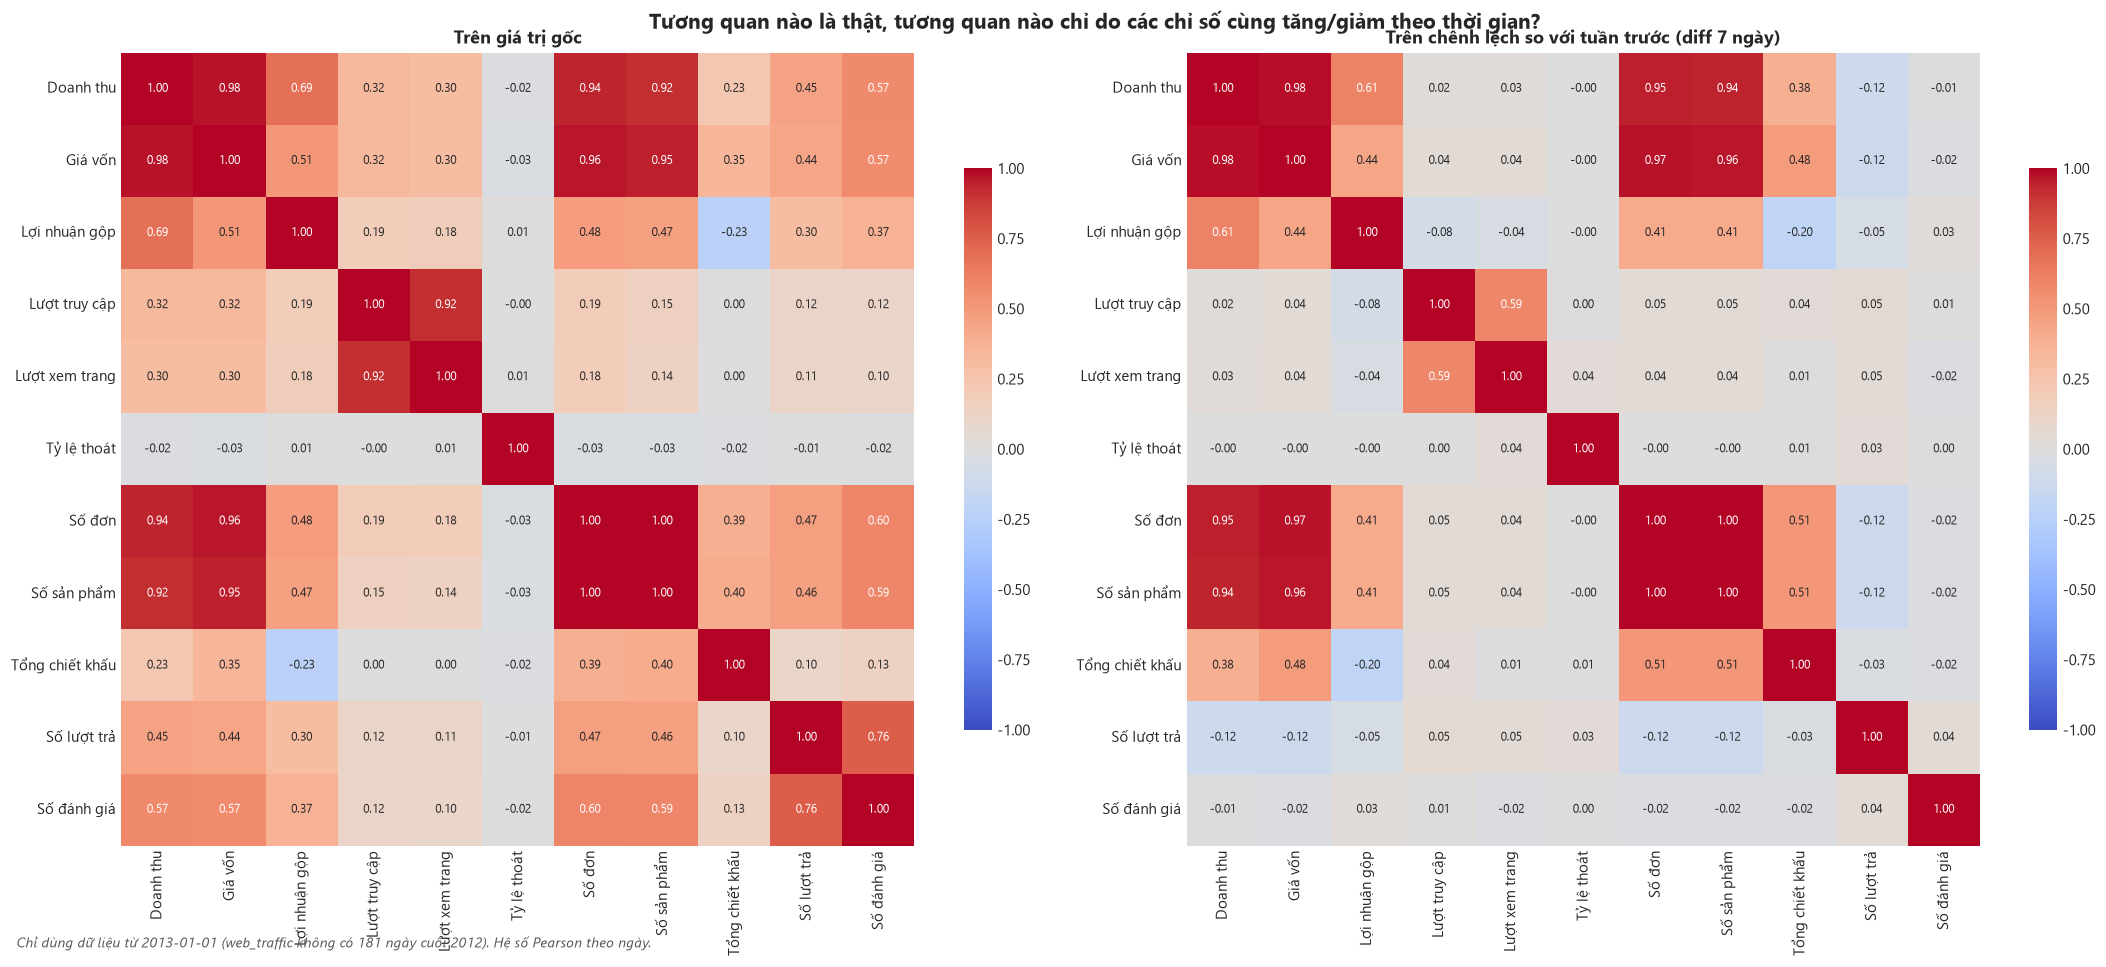

  đã lưu 04a_tuong_quan_goc_vs_diff.png


,tuong_quan_goc,tuong_quan_diff7,chenh
Số đánh giá,0.572,-0.014,0.586
Số lượt trả,0.451,-0.116,0.566
Lượt truy cập,0.321,0.022,0.299
Lượt xem trang,0.302,0.029,0.272
Tổng chiết khấu,0.234,0.385,-0.150
Lợi nhuận gộp,0.687,0.609,0.078
Số sản phẩm,0.922,0.943,-0.021
Tỷ lệ thoát,-0.021,-0.004,-0.016
Số đơn,0.938,0.949,-0.011
Giá vốn,0.976,0.980,-0.004


In [3]:
raw = p13[list(VN)].rename(columns=VN)
diff = raw.diff(7)          # chênh lệch so với cùng thứ tuần trước
c_raw, c_diff = raw.corr(), diff.corr()
fig, axes = plt.subplots(1, 2, figsize=(20, 8.5))
for ax, c, title in [(axes[0], c_raw, "Trên giá trị gốc"), (axes[1], c_diff, "Trên chênh lệch so với tuần trước (diff 7 ngày)")]:
    sns.heatmap(c, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"shrink": 0.7}, annot_kws={"size": 8})
    ax.set_title(title, fontweight="bold")
fig.suptitle("Tương quan nào là thật, tương quan nào chỉ do các chỉ số cùng tăng/giảm theo thời gian?", fontsize=14, fontweight="bold")
fig.tight_layout()
source_note(fig, NOTE_TRAFFIC + " Hệ số Pearson theo ngày.")
save_fig(fig, FIG / "04a_tuong_quan_goc_vs_diff.png")

rev_corr = pd.DataFrame({"tuong_quan_goc": c_raw["Doanh thu"], "tuong_quan_diff7": c_diff["Doanh thu"]}).drop("Doanh thu")
rev_corr["chenh"] = rev_corr.tuong_quan_goc - rev_corr.tuong_quan_diff7
rev_corr = rev_corr.sort_values("chenh", key=abs, ascending=False)
rev_corr.to_csv(TAB / "tuong_quan_voi_doanh_thu.csv", encoding="utf-8-sig")
rev_corr.round(3)

In [4]:
key_numbers({
    "Tương quan Doanh thu – Lượt truy cập (gốc / diff7)": f"{c_raw.loc['Doanh thu', 'Lượt truy cập']:.3f} / {c_diff.loc['Doanh thu', 'Lượt truy cập']:.3f}",
    "Tương quan Doanh thu – Số đơn (gốc / diff7)": f"{c_raw.loc['Doanh thu', 'Số đơn']:.3f} / {c_diff.loc['Doanh thu', 'Số đơn']:.3f}",
    "Tương quan Doanh thu – Tổng chiết khấu (gốc / diff7)": f"{c_raw.loc['Doanh thu', 'Tổng chiết khấu']:.3f} / {c_diff.loc['Doanh thu', 'Tổng chiết khấu']:.3f}",
    "Chỉ số giảm tương quan nhiều nhất sau diff7": f"{rev_corr.chenh.idxmax()} ({rev_corr.chenh.max():+.3f})",
})

Số liệu chính:
  - Tương quan Doanh thu – Lượt truy cập (gốc / diff7): 0.321 / 0.022
  - Tương quan Doanh thu – Số đơn (gốc / diff7): 0.938 / 0.949
  - Tương quan Doanh thu – Tổng chiết khấu (gốc / diff7): 0.234 / 0.385
  - Chỉ số giảm tương quan nhiều nhất sau diff7: Số đánh giá (+0.586)


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Lượt truy cập và số đơn liên hệ với doanh thu ngày thế nào?

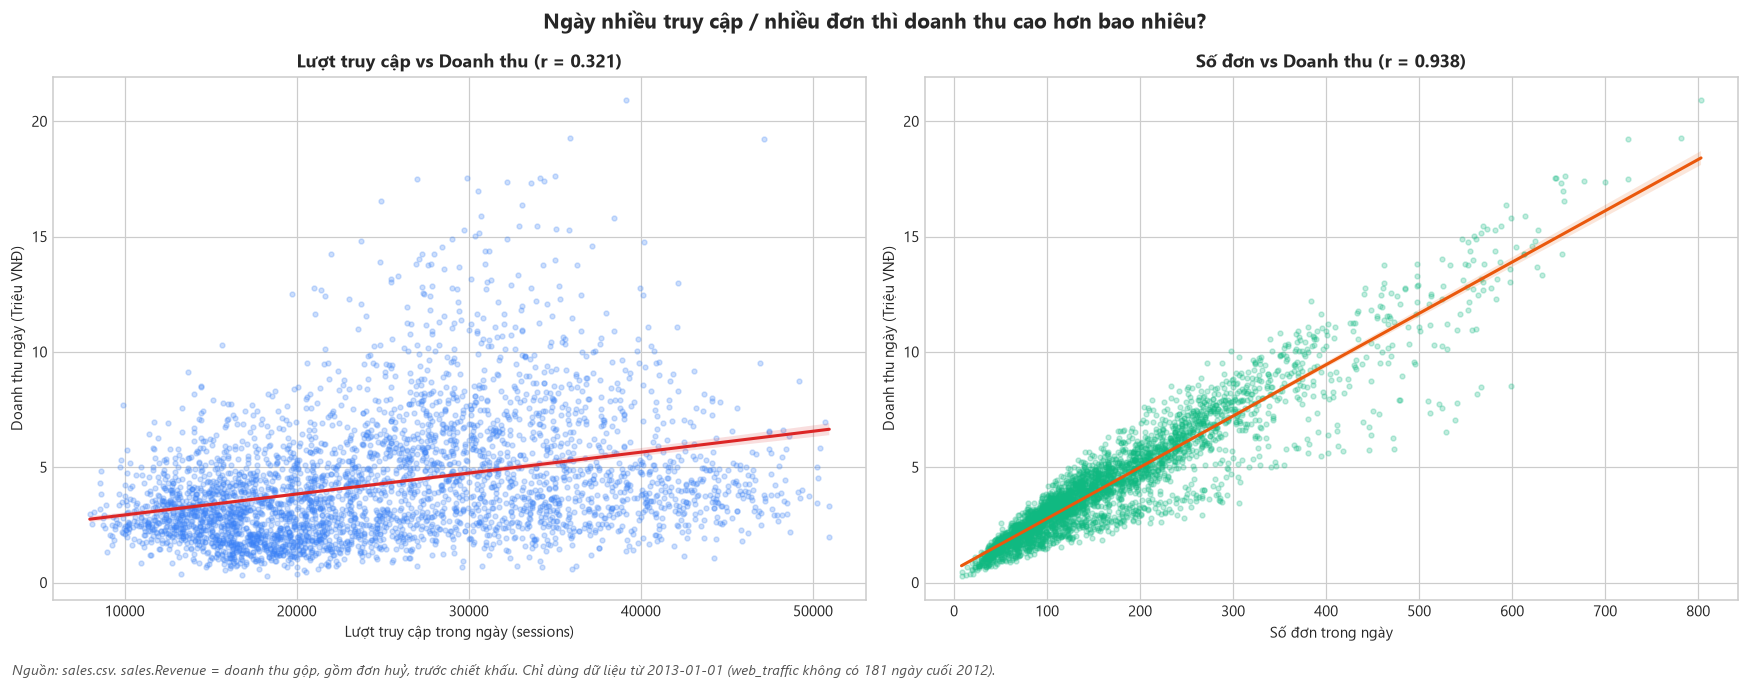

  đã lưu 04b_traffic_don_hang_vs_doanh_thu.png


In [5]:
import scipy.stats as st
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
rs = {}
for ax, col, c1, c2, xlab in [(axes[0], "total_sessions", "#3b82f6", "#dc2626", "Lượt truy cập trong ngày (sessions)"),
                              (axes[1], "order_count", "#10b981", "#ea580c", "Số đơn trong ngày")]:
    r = st.pearsonr(p13[col], p13.Revenue)
    rs[col] = r
    sns.regplot(x=p13[col], y=p13.Revenue / MILLION, ax=ax, scatter_kws={"alpha": 0.25, "s": 10, "color": c1}, line_kws={"color": c2, "lw": 2})
    ax.set_title(f"{VN[col]} vs Doanh thu (r = {r.statistic:.3f})", fontweight="bold")
    ax.set_xlabel(xlab)
    ax.set_ylabel(f"Doanh thu ngày ({UNIT})")
fig.suptitle("Ngày nhiều truy cập / nhiều đơn thì doanh thu cao hơn bao nhiêu?", fontsize=14, fontweight="bold")
fig.tight_layout()
source_note(fig, NOTE_SALES + " " + NOTE_TRAFFIC)
save_fig(fig, FIG / "04b_traffic_don_hang_vs_doanh_thu.png")

In [6]:
conv = p13.order_count / p13.total_sessions * 100
aov = p13.Revenue / p13.order_count
key_numbers({
    "r(sessions, doanh thu) / r(số đơn, doanh thu)": f"{rs['total_sessions'].statistic:.3f} / {rs['order_count'].statistic:.3f}",
    "Tỷ lệ chuyển đổi đơn/lượt truy cập: trung vị": f"{conv.median():.2f}% (p5–p95: {conv.quantile(0.05):.2f}% – {conv.quantile(0.95):.2f}%)",
    "Doanh thu trung bình mỗi đơn (gộp): trung vị": f"{aov.median():,.0f} đồng",
    "Lượt truy cập/ngày: min – max": f"{p13.total_sessions.min():,.0f} – {p13.total_sessions.max():,.0f}",
})

Số liệu chính:
  - r(sessions, doanh thu) / r(số đơn, doanh thu): 0.321 / 0.938
  - Tỷ lệ chuyển đổi đơn/lượt truy cập: trung vị: 0.63% (p5–p95: 0.20% – 1.73%)
  - Doanh thu trung bình mỗi đơn (gộp): trung vị: 26,871 đồng
  - Lượt truy cập/ngày: min – max: 7,973 – 50,947


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Doanh thu thay đổi thế nào khi kết hợp mức truy cập và mức chiết khấu?

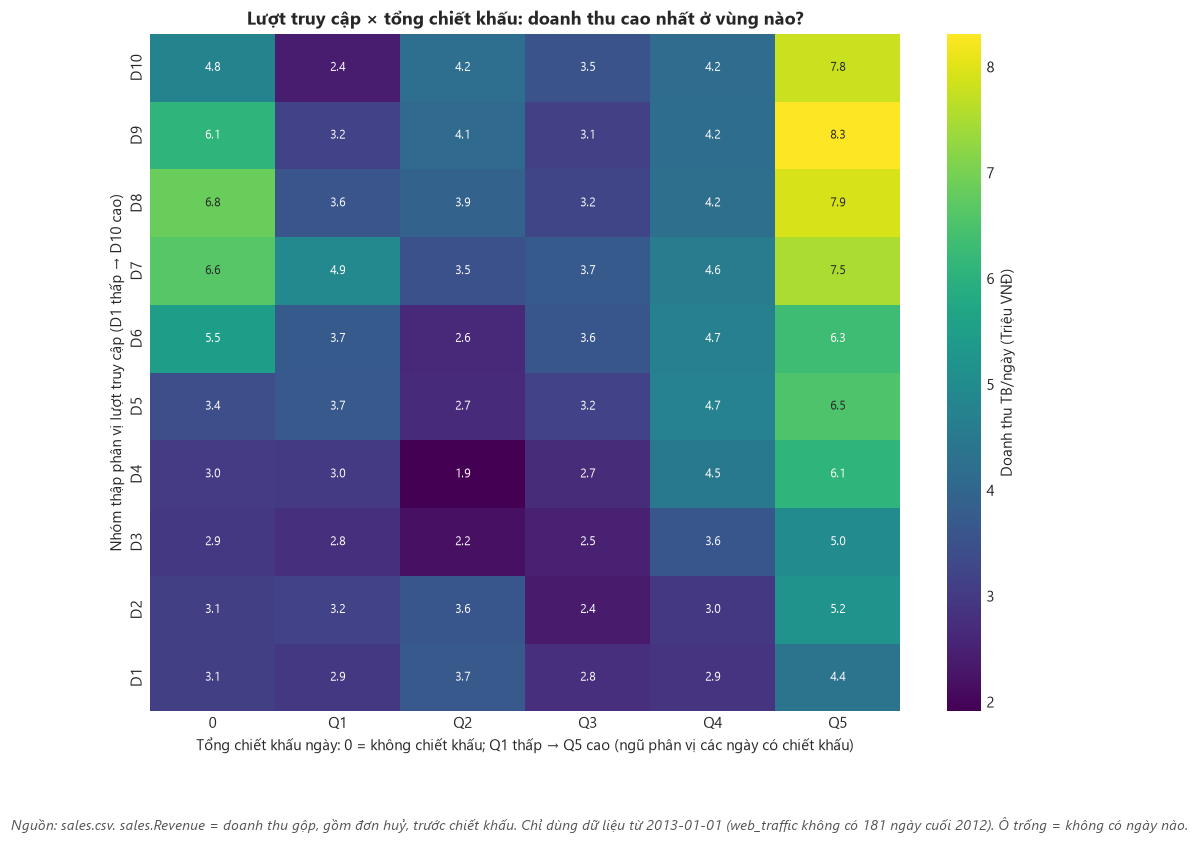

  đã lưu 04c_traffic_x_chiet_khau.png


In [7]:
t_q = pd.qcut(p13.total_sessions, 10, labels=[f"D{i}" for i in range(1, 11)])
# > 50% số ngày có tổng chiết khấu = 0 → nhóm riêng "0", các ngày còn lại chia 5 nhóm ngũ phân vị
disc = p13.total_discounts_applied
d_q = pd.Series("0", index=p13.index)
d_q[disc > 0] = pd.qcut(disc[disc > 0], 5, labels=[f"Q{i}" for i in range(1, 6)]).astype(str)
d_q = pd.Series(pd.Categorical(d_q, categories=["0"] + [f"Q{i}" for i in range(1, 6)], ordered=True), index=p13.index, name="nhom_chiet_khau")
t_q = t_q.rename("nhom_truy_cap")
surf = p13.pivot_table(index=t_q, columns=d_q, values="Revenue", aggfunc="mean", observed=False) / MILLION
cnt = p13.pivot_table(index=t_q, columns=d_q, values="Revenue", aggfunc="count", observed=False)
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(surf, cmap="viridis", annot=True, fmt=".1f", annot_kws={"size": 8}, ax=ax, cbar_kws={"label": f"Doanh thu TB/ngày ({UNIT})"})
ax.invert_yaxis()
ax.set_title("Lượt truy cập × tổng chiết khấu: doanh thu cao nhất ở vùng nào?", fontweight="bold")
ax.set_xlabel("Tổng chiết khấu ngày: 0 = không chiết khấu; Q1 thấp → Q5 cao (ngũ phân vị các ngày có chiết khấu)")
ax.set_ylabel("Nhóm thập phân vị lượt truy cập (D1 thấp → D10 cao)")
source_note(fig, NOTE_SALES + " " + NOTE_TRAFFIC + " Ô trống = không có ngày nào.")
save_fig(fig, FIG / "04c_traffic_x_chiet_khau.png")

In [8]:
key_numbers({
    "Ô doanh thu TB cao nhất": f"truy cập {surf.stack().idxmax()[0]}, chiết khấu {surf.stack().idxmax()[1]} ({surf.max().max():.2f} {UNIT})",
    "Ô doanh thu TB thấp nhất": f"truy cập {surf.stack().idxmin()[0]}, chiết khấu {surf.stack().idxmin()[1]} ({surf.min().min():.2f} {UNIT})",
    "% ngày không có chiết khấu": f"{(disc == 0).mean() * 100:.1f}%",
    "Số ô trống / có < 10 ngày": f"{int(surf.isna().sum().sum())} / {int((cnt < 10).sum().sum())} trên {surf.size} ô",
    "Tương quan Spearman sessions – chiết khấu": f"{st.spearmanr(p13.total_sessions, p13.total_discounts_applied).statistic:.3f}",
})

Số liệu chính:
  - Ô doanh thu TB cao nhất: truy cập D9, chiết khấu Q5 (8.31 Triệu VNĐ)
  - Ô doanh thu TB thấp nhất: truy cập D4, chiết khấu Q2 (1.91 Triệu VNĐ)
  - % ngày không có chiết khấu: 53.3%
  - Số ô trống / có < 10 ngày: 0 / 1 trên 60 ô
  - Tương quan Spearman sessions – chiết khấu: -0.023


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Có những trạng thái vận hành điển hình nào? (PCA + K-means, k = 4)

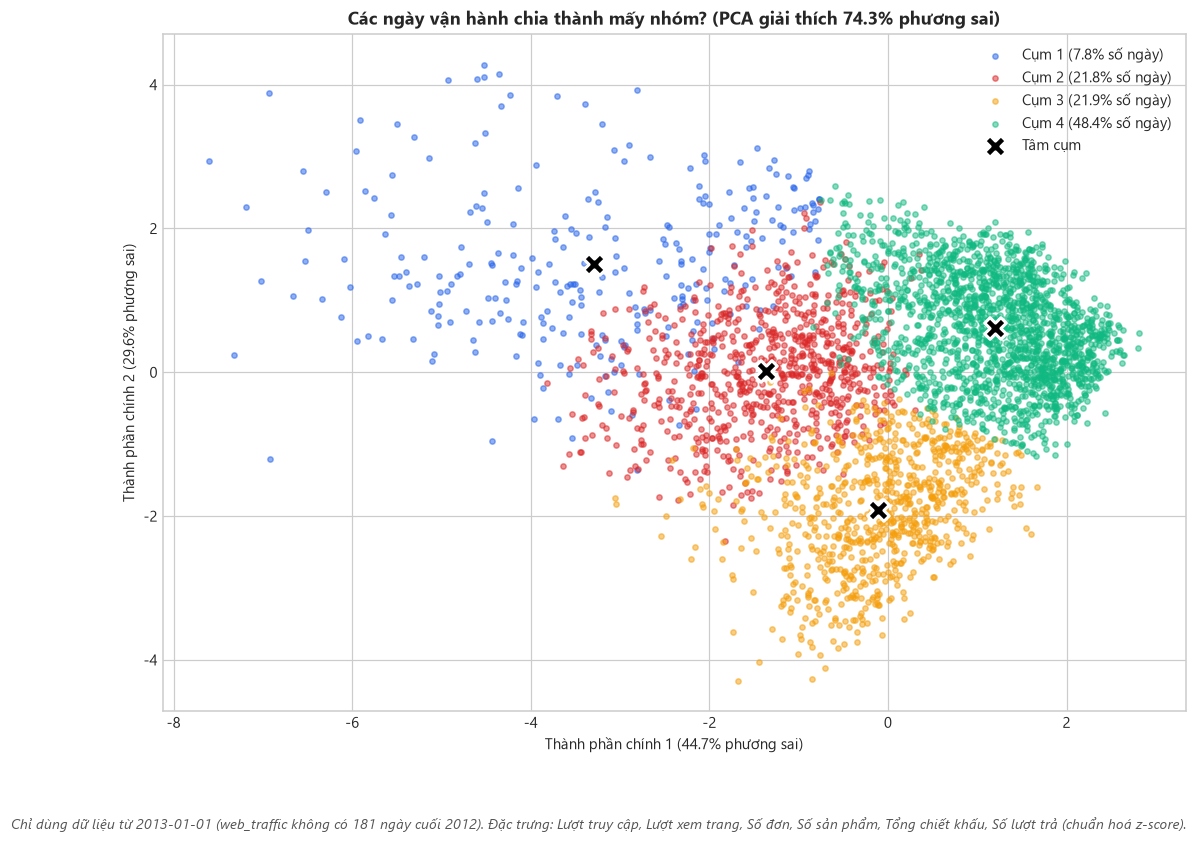

  đã lưu 04d_cum_trang_thai_van_hanh.png


,PC1,PC2
Lượt truy cập,-0.298,-0.635
Lượt xem trang,-0.294,-0.638
Số đơn,-0.558,0.219
Số sản phẩm,-0.549,0.248
Tổng chiết khấu,-0.281,0.251
Số lượt trả,-0.365,0.131


In [9]:
FEAT = ["total_sessions", "total_page_views", "order_count", "total_units_ordered", "total_discounts_applied", "return_count"]
X = p13[FEAT].to_numpy(float)
Xs = (X - X.mean(axis=0)) / X.std(axis=0)
e_val, e_vec = np.linalg.eigh(np.cov(Xs, rowvar=False))
order = np.argsort(e_val)[::-1]
e_val, e_vec = e_val[order], e_vec[:, order]
pc = Xs @ e_vec[:, :2]
var_exp = e_val[:2] / e_val.sum()

# K-means cài bằng NumPy (giữ như code gốc), seed cố định
rng = np.random.default_rng(42)
k = 4
centers = Xs[rng.choice(len(Xs), k, replace=False)]
for _ in range(100):
    labels = np.argmin(np.linalg.norm(Xs[:, None] - centers, axis=2), axis=1)
    new = np.array([Xs[labels == i].mean(axis=0) if (labels == i).any() else centers[i] for i in range(k)])
    if np.allclose(centers, new):
        break
    centers = new
p13["cum"] = labels + 1

fig, ax = plt.subplots(figsize=(12, 8))
pal = ["#2563eb", "#dc2626", "#f59e0b", "#10b981"]
for i in range(k):
    m = labels == i
    ax.scatter(pc[m, 0], pc[m, 1], s=12, alpha=0.5, c=pal[i], label=f"Cụm {i + 1} ({m.mean() * 100:.1f}% số ngày)")
cp = centers @ e_vec[:, :2]
ax.scatter(cp[:, 0], cp[:, 1], c="black", s=200, marker="X", edgecolor="white", lw=2, label="Tâm cụm")
ax.set_title(f"Các ngày vận hành chia thành mấy nhóm? (PCA giải thích {var_exp.sum() * 100:.1f}% phương sai)", fontweight="bold")
ax.set_xlabel(f"Thành phần chính 1 ({var_exp[0] * 100:.1f}% phương sai)")
ax.set_ylabel(f"Thành phần chính 2 ({var_exp[1] * 100:.1f}% phương sai)")
ax.legend()
source_note(fig, NOTE_TRAFFIC + " Đặc trưng: " + ", ".join(VN[f] for f in FEAT) + " (chuẩn hoá z-score).")
save_fig(fig, FIG / "04d_cum_trang_thai_van_hanh.png")

loadings = pd.DataFrame(e_vec[:, :2], index=[VN[f] for f in FEAT], columns=["PC1", "PC2"])
display(loadings.round(3))

In [10]:
prof = p13.groupby("cum").agg(
    so_ngay=("Date", "count"), **{VN[f]: (f, "mean") for f in FEAT},
    doanh_thu_tb_trieu=("Revenue", lambda s: s.mean() / MILLION), bien_gop_tb_pct=("Gross_Margin_Pct", "mean"),
    thang_pho_bien=("Month", lambda s: s.mode().iat[0]), ty_le_cuoi_tuan_pct=("IsWeekend", lambda s: s.mean() * 100))
prof.insert(1, "ty_le_ngay_pct", prof.so_ngay / prof.so_ngay.sum() * 100)
prof.to_csv(TAB / "cluster_profile.csv", encoding="utf-8-sig")
print("Bảng đặc điểm tâm cụm (giá trị trung bình theo cụm) – nhóm dùng để đặt tên cụm:")
display(prof.round(2))
key_numbers({
    "Cụm có doanh thu TB cao nhất / thấp nhất": f"Cụm {prof.doanh_thu_tb_trieu.idxmax()} ({prof.doanh_thu_tb_trieu.max():.2f}) / Cụm {prof.doanh_thu_tb_trieu.idxmin()} ({prof.doanh_thu_tb_trieu.min():.2f}) {UNIT}",
    "Cụm lớn nhất": f"Cụm {prof.so_ngay.idxmax()} ({prof.ty_le_ngay_pct.max():.1f}% số ngày)",
    "Phương sai giải thích PC1 / PC2": f"{var_exp[0] * 100:.1f}% / {var_exp[1] * 100:.1f}%",
})

Bảng đặc điểm tâm cụm (giá trị trung bình theo cụm) – nhóm dùng để đặt tên cụm:


,so_ngay,ty_le_ngay_pct,Lượt truy cập,Lượt xem trang,Số đơn,Số sản phẩm,Tổng chiết khấu,Số lượt trả,doanh_thu_tb_trieu,bien_gop_tb_pct,thang_pho_bien,ty_le_cuoi_tuan_pct
cum,,,,,,,,,,,,
1,285,7.80,25775.65,111997.20,426.29,2159.26,823980.77,13.18,9.35,7.33,6,23.86
2,797,21.82,28466.70,123154.25,244.77,1201.84,182151.53,17.98,6.17,12.27,5,27.35
3,801,21.93,37306.93,164439.98,127.10,604.53,146357.31,7.69,3.81,10.27,8,29.21
4,1769,48.44,17826.83,76242.64,111.08,559.29,142660.16,7.86,2.86,13.70,1,29.56


Số liệu chính:
  - Cụm có doanh thu TB cao nhất / thấp nhất: Cụm 1 (9.35) / Cụm 4 (2.86) Triệu VNĐ
  - Cụm lớn nhất: Cụm 4 (48.4% số ngày)
  - Phương sai giải thích PC1 / PC2: 44.7% / 29.6%


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …